**Simulated Sensor Data**

We simulate accelerometer magnitude values representing three activities.


| Activity | Hidden State | Observation Range (Motion Intensity) |
| -------- | ------------ | ------------------------------------ |
| Sitting  | 0            | very low values                      |
| Walking  | 1            | medium values                        |
| Running  | 2            | high values                          |


**Example observation sequence:**

0.1 → 0.2 → 0.15 → 1.2 → 1.4 → 1.3 → 3.5 → 3.8 → 3.7

**Expected hidden states:**

Sitting → Sitting → Sitting → Walking → Walking → Walking → Running → Running → Running

The HMM will learn patterns and predict the hidden activity sequence.

**Installation and Imports**

In [31]:
!pip install hmmlearn

In [32]:
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt

**Generate Synthetic Sensor Data**

In [33]:
np.random.seed(42)
# Sitting activity (low motion)
sitting = np.random.normal(0.2, 0.02, 150)
# Walking activity (moderate motion)
walking = np.random.normal(1.2, 0.05, 150)
# Running activity (high motion)
running = np.random.normal(3.5, 0.1, 150)
# Combine sequences
observations = np.concatenate([sitting, walking, running])
# True hidden states for evaluation
true_states = np.array([0] * 150 + [1] * 150 + [2] * 150)
# Reshape for HMM
X = observations.reshape(-1,1)

**Shuffle the dataset.**

In [34]:
indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
true_states = true_states[indices]

**Create the Hidden Markov Model**

n_components = 3 represents the three hidden activities.

In [35]:
model = hmm.GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=1000,
    random_state=42,
    init_params=""
)

**Define emission means for each hidden activity.**

In [36]:
model.means_ = np.array([
    [0.2],   # sitting
    [1.2],   # walking
    [3.5]    # running
])

**Define start probabilities.**

In [37]:
model.startprob_ = np.array([0.33,0.33,0.34])

**Define transition probability matrix.**

In [38]:
model.transmat_ = np.array([
    [0.7,0.2,0.1],
    [0.2,0.6,0.2],
    [0.1,0.3,0.6]
])

**Train the Model**

The model learns:

* Transition probabilities

* Emission distributions

* State parameters

In [39]:
model.fit(X)

GaussianHMM(init_params='', n_components=3, n_iter=1000, random_state=42)

**Predict Hidden Activities**

In [40]:
predicted_states = model.predict(X)

# Display 5 random predictions
for i in range(5):
    idx = np.random.randint(0, len(observations))
    print(f"Observation: {observations[idx]:.2f} → Predicted State: {predicted_states[idx]}")

Observation: 1.15 → Predicted State: 2
Observation: 1.21 → Predicted State: 0
Observation: 0.18 → Predicted State: 2
Observation: 0.18 → Predicted State: 0
Observation: 0.20 → Predicted State: 2


**1: Sequence Likelihood:** Compute probability that the observation sequence was generated by the model.

In [41]:
log_likelihood = model.score(X)

print("Log Likelihood of observation sequence:", log_likelihood)

Log Likelihood of observation sequence: 264.8164337530453


**2: Posterior State Probabilities:** Probability of each hidden state at every time step.

In [42]:
state_probabilities = model.predict_proba(X)

print("Posterior probabilities for first 2 observations:")
print(state_probabilities[:2])

Posterior probabilities for first 2 observations:
[[0.00000000e+000 0.00000000e+000 1.00000000e+000]
 [0.00000000e+000 1.00000000e+000 1.32488012e-124]]


**3: Generate Sample Sequence from Model:** Generate synthetic observations using the trained HMM.

In [43]:
sample_observations, sample_states = model.sample(5)

print("Generated observations:")
print(sample_observations)

print("Generated hidden states:")
print(sample_states)

Generated observations:
[[3.39988308]
 [0.20488514]
 [0.20406872]
 [3.60148426]
 [0.18645606]]
Generated hidden states:
[2 0 0 2 0]


**View Model Parameters**

In [44]:
# Start Probabilities
print("Start Probabilities:")
print(model.startprob_)
# Transition Matrix
print("\nTransition Matrix:")
print(model.transmat_)
# State Means(Emission Parameters)
print("\nMeans of Hidden states:")
print(model.means_)

Start Probabilities:
[0. 0. 1.]

Transition Matrix:
[[0.34666667 0.32666667 0.32666667]
 [0.36241611 0.30201342 0.33557047]
 [0.29333333 0.37333333 0.33333333]]

Means of Hidden states:
[[0.19835346]
 [1.20356149]
 [3.50549787]]


**Visualize Predicted Activities**

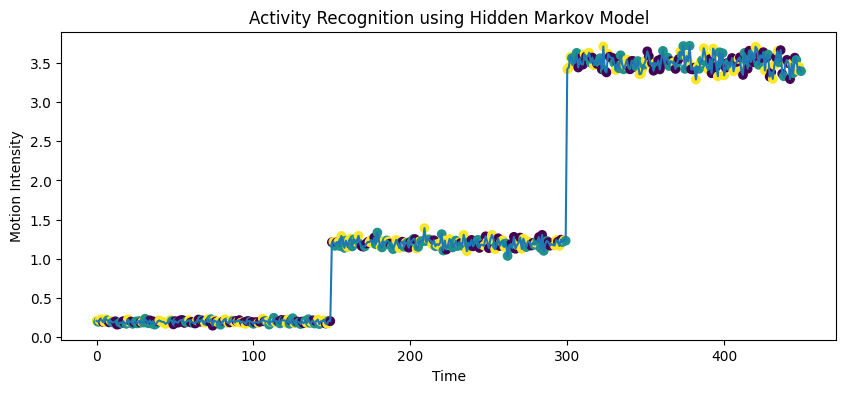

In [45]:
plt.figure(figsize=(10,4))
plt.plot(observations, label="Sensor Observations")
plt.scatter(range(len(predicted_states)), observations, c=predicted_states, cmap='viridis')
plt.title("Activity Recognition using Hidden Markov Model")
plt.xlabel("Time")
plt.ylabel("Motion Intensity")
plt.show()

**Conclusion**

A Hidden Markov Model was successfully implemented using hmmlearn. The model learned probabilistic state transitions and emission distributions from simulated sensor data. It was used to decode hidden activities, compute state probabilities, evaluate sequence likelihood, and generate new observation sequences.